# Biology 1C: Discovery, Week 6 Workshop

Analyse colony counts data from the class practicals week 3. The questions we are asking are:

- Do more colonies grow on LB agar compared to SC agar?
- Do more colonies grow for different Workshop groups?

You are encouraged to work on this within the groups at your tables in the workshop, and discuss with your fellow students.

This material builds on the data analysis workshop in Week 5, in the file `DiscoWorkshop5_2026-02-10.ipynb`. You may want to refer to your notes from that workshop, and re-use some examples of code from that analysis, here. The Week 5 folder also has a worked answers file released of that notebook, if you would like to refer to that.


## Load the python packages and functions needed for the workshop

We will load the packages to analyse the data.

In [1]:
# first load python packages
import pandas as pd # pandas data frames
import numpy as np # numpy for various calculations
from scipy import stats # statistics functions
import math  # for the square root function
import seaborn as sns # friendly plotting functions including histograms
import matplotlib.pyplot as plt # other plotting functions including subplots and axis lines


## Load the data

We will load data of colony counts from the class workshops, in the file `DiscoveryPractical3ColonyCounts2026.xlsx`.

This file only includes counts from the $10^{-4}$ (ten to the minus 4) dilution. It has columns:

- ID - Unique Sample ID for each row
- Session - Answer to "What session are you in?", e.g. `A Wednesday AM`
- Group - Answer to "What group are you in?", should be an integer between 1 and 15
- ColonyCountsLBagar - Answer to "In LB agar, how many colonies do you have in the plates for your pair." Should be a positive integer.
- ColonyTypesLBagar - Answer to "In LB agar, how many different colony types do you have in the plates for your pair." Should be a positive integer.
- ColonyCountsSCagar - Answer to "In Starch Casein agar, how many colonies do you have in the plates for your pair." Should be a positive integer.
- ColonyTypesSCagar - Answer to "In Starch Casein agar, how many different colony types do you have in the plates for your pair." Should be a positive integer.


In [2]:
countdata = pd.read_excel("DiscoveryPractical3ColonyCounts2026.xlsx")

countdata

,ID,Session,Group,ColonyCountsLBagar,ColonyTypesLBagar,ColonyCountsSCagar,ColonyTypesSCagar
0,1,C Thursday PM,8,16.0,3.0,17.0,11.0
1,2,C Thursday PM,10,15.0,11.0,14.0,4.0
2,3,B Wednesday PM,6,13.0,6.0,9.0,4.0
3,4,A Wednesday AM,15,5.0,2.0,4.0,1.0
4,5,C Thursday PM,3,16.0,6.0,6.0,5.0
5,6,C Thursday PM,6,238.0,4.0,4.0,3.0
6,7,A Wednesday AM,15,8.0,3.0,12.0,4.0
7,8,C Thursday PM,9,8.0,6.0,3.0,7.0
8,9,C Thursday PM,10,30.0,3.0,12.0,6.0
9,10,C Thursday PM,14,12.0,6.0,13.0,4.0


Let's use the describe function to see the statistics of these counts (mean, standard deviation, etc.)

In [3]:
countdata.describe()

,ID,Group,ColonyCountsLBagar,ColonyTypesLBagar,ColonyCountsSCagar,ColonyTypesSCagar
count,42.000000,42.000000,40.000000,39.000000,41.000000,40.000000
mean,21.500000,8.238095,25.800000,5.692308,21.097561,4.300000
std,12.267844,4.541460,40.133879,3.403975,33.007427,2.377243
min,1.000000,1.000000,4.000000,1.000000,2.000000,1.000000
25%,11.250000,4.000000,7.750000,3.500000,5.000000,3.000000
50%,21.500000,7.500000,13.000000,5.000000,9.000000,4.000000
75%,31.750000,13.000000,22.500000,6.500000,18.000000,6.000000
max,42.000000,16.000000,238.000000,18.000000,154.000000,11.000000


Think here: based on these statistics such as the mean, what do you now think are likely answers to the question:

- Do more colonies grow on LB agar compared to SC agar?

*Note: do the statistics on the `ID` and `Group` columns make sense? Why or why not?* 


# Plotting the data LB agar vs SC agar

Let's plot the data to understand it, focusing on the question "Do more colonies grow on LB agar compared to SC agar?"

First plot a histogram of the Colony Counts in LB agar, then in SC agar.

*Note: although in workshop 5 we used the argument "discrete=True" to nicely display the small integers on a histogram, that doesn't make much of a difference in this dataset.*

<Axes: xlabel='ColonyCountsLBagar', ylabel='Count'>

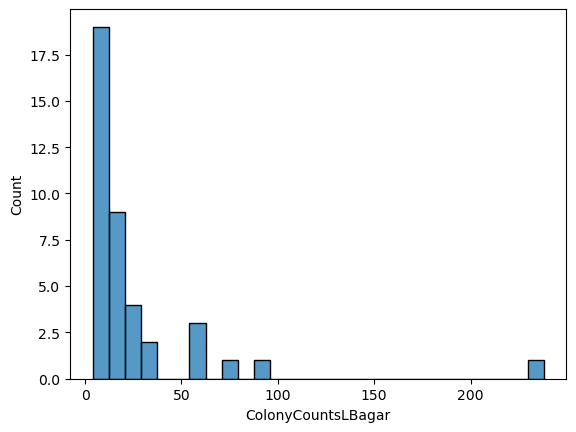

In [4]:
# Colony counts in LB agar
sns.histplot(data = countdata, x = "ColonyCountsLBagar")

<Axes: xlabel='ColonyCountsSCagar', ylabel='Count'>

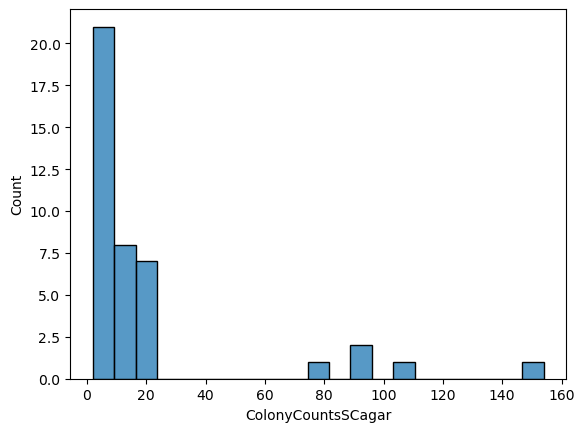

In [5]:
# Colony counts in SC agar
sns.histplot(data = countdata, x = "ColonyCountsSCagar")

How does this look? What do you think about the variability and comparability of the data?

To compare the datasets, try making the following adjustments:

1. Plot both plots again, stacked as subplots, with the same limits and bin values.
2. Add a vertical line for the mean, in a different colour.
3. Add a vertical line for the median, in another different colour.

You can adapt the code from the previous workshop, in the code chunk beginning `# plot the two population histograms on matched axes.` To get this to work, you'll need to:

- change the name of the data frame
- change the name of the variable
- and change those names in both the histogram plot and in the vertical line plotting

You might also want to build this up in pieces - first setting the binrange, then after that's looking good add the vertical lines. You should be able to plot the median line by duplicating the line of code that plots the mean, and editing the duplicate to show the median (in a different colour) instead.

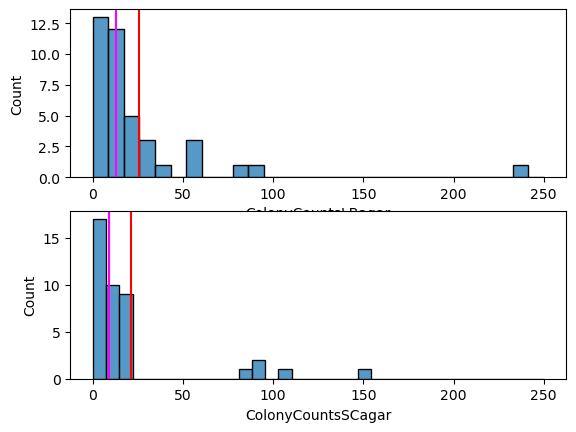

In [6]:
# edit most out for students
# plot the two population histograms on matched axes.
value_min = 0 
value_max = 250

fig, (ax1, ax2) = plt.subplots(2)
sns.histplot(data = countdata, 
                   x = "ColonyCountsLBagar", 
                   binrange = [value_min, value_max],
            ax = ax1)
ax1.axvline( countdata["ColonyCountsLBagar"].mean(), color = "red")
ax1.axvline( countdata["ColonyCountsLBagar"].median(), color = "magenta")
sns.histplot(data = countdata, 
                   x = "ColonyCountsSCagar",
                   binrange = [value_min, value_max],
                  ax = ax2)
ax2.axvline( countdata["ColonyCountsSCagar"].mean(), color = "red")
ax2.axvline( countdata["ColonyCountsSCagar"].median(), color = "magenta")

## Statistical tests of colony counts on different media

At this point, you might think you know what the outcome of a statistical test might be. However, the data are highly variable so it's difficult to guess in advance the outcome of a test. Remember, the overall idea of many statistical tests is: "is the difference greater than the variability".

In particular, to ask about differences in mean colony counts, we want to know something about the difference in means relative to the standard error of the mean.

First we will need to check how many samples there are, this should be the number of rows in the data.

*Note: it would be even better to check the number of **non-missing** samples... try this if you would like. If so, the pandas function [`pandas.DataFrame.count` (link to help page here)](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.count.html) may be useful.*

In [7]:
# calculate number of samples
nsamples = len(countdata)
nsamples

42

Now, you should be able to calculate the means and standard errors for counts on LB agar and SC agar, by adapting code from the week 5 workshop in the code chunk beginning `# calculate means and sems of both populations`.

Some tips:

- you can use copy/paste and tab-autocomplete to replace the names of data frame and columns
- if you see an error, don't panic! It's most likely a typo, you can find it and fix it
- if in doubt, run lines of code one by one in a separate code chunk until they work

In [8]:
# sample means and standard errors
smean_LB = countdata["ColonyCountsLBagar"].mean()
sstd_LB  = countdata["ColonyCountsLBagar"].std()
SEM_LB = sstd_LB / math.sqrt(nsamples)

print(f"sample mean LB agar = {smean_LB:.2f}")
print(f'st.d. LB agar = {sstd_LB:.2f} ')
print(f'SEM LB agar = {SEM_LB:.2f}')

smean_SC = countdata["ColonyCountsSCagar"].mean()
sstd_SC  = countdata["ColonyCountsSCagar"].std()
SEM_SC = sstd_SC / math.sqrt(nsamples)

print(f"sample mean SC agar = {smean_SC:.2f}")
print(f'st.d. SC agar = {sstd_SC:.2f} ')
print(f'SEM SC agar = {SEM_SC:.2f}')


sample mean LB agar = 25.80
st.d. LB agar = 40.13 
SEM LB agar = 6.19
sample mean SC agar = 21.10
st.d. SC agar = 33.01 
SEM SC agar = 5.09


Ok, now it's time to do the statistical test. Here we can use a t-test, and you can adapt the code in workshop 5 from the code chunk `# use the two sample t-test function from scipy.stats`


In [9]:
# use the two sample t-test function from scipy.stats
# partially edit out for students, to replace the variables

# Perform the two sample t-test on the colony counts
t, p = stats.ttest_ind( countdata["ColonyCountsLBagar"], countdata["ColonyCountsSCagar"])

# Print t 2 decimal places
print(f't = {t:.2f}')

# Print the p-value to 4 decimal places
print(f'p-value = {p:.4f}')

t = nan
p-value = nan


Oh no, what happened? If you did this directly adapting the code from last time, then it may be that missing values in the data led to the test giving you a `nan` or missing output.

We can address this by doing the test again and changing how the t-test treats missing values. Try adding the parameter `nan_policy = 'omit'`. For more information on the t-test function, you could read [the documentation for `stats.ttest_ind` (linked here)](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html).

Try that below.

In [10]:
# use the two sample t-test function from scipy.stats, but with nan_policy = `omit`

# Perform the two sample t-test on the colony counts
t, p = stats.ttest_ind( countdata["ColonyCountsLBagar"], countdata["ColonyCountsSCagar"], nan_policy = 'omit')

# Print t 2 decimal places
print(f't = {t:.2f}')

# Print the p-value to 4 decimal places
print(f'p-value = {p:.4f}')

t = 0.58
p-value = 0.5659


# Comparing colony counts across groups.

We'll now move to the question "Do more colonies grow for different Workshop groups?".

*Tip: Before continuing, double-check that the data loaded in countdata is still behaving as you expect. It's easy to accidentally overwrite data in a Python session. If something looks strange, reload the data by re-running the code chunk that first loaded the data.*

In [11]:
# double-check that countdata behaves as expected.
countdata

,ID,Session,Group,ColonyCountsLBagar,ColonyTypesLBagar,ColonyCountsSCagar,ColonyTypesSCagar
0,1,C Thursday PM,8,16.0,3.0,17.0,11.0
1,2,C Thursday PM,10,15.0,11.0,14.0,4.0
2,3,B Wednesday PM,6,13.0,6.0,9.0,4.0
3,4,A Wednesday AM,15,5.0,2.0,4.0,1.0
4,5,C Thursday PM,3,16.0,6.0,6.0,5.0
5,6,C Thursday PM,6,238.0,4.0,4.0,3.0
6,7,A Wednesday AM,15,8.0,3.0,12.0,4.0
7,8,C Thursday PM,9,8.0,6.0,3.0,7.0
8,9,C Thursday PM,10,30.0,3.0,12.0,6.0
9,10,C Thursday PM,14,12.0,6.0,13.0,4.0


## Plotting the data between groups

To do this, we need to plot so that the different groups' values are differentially displayed. As you saw above, the groups are in the column "Session".

<Axes: xlabel='ColonyCountsLBagar', ylabel='Count'>

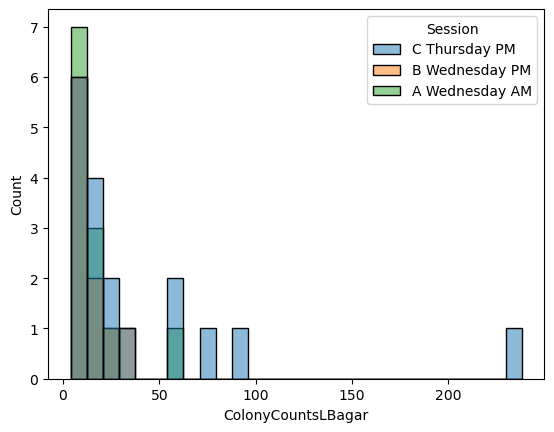

In [12]:
# histogram in LB agar by group
sns.histplot(data = countdata, x = "ColonyCountsLBagar", hue = "Session")

<Axes: xlabel='ColonyCountsSCagar', ylabel='Count'>

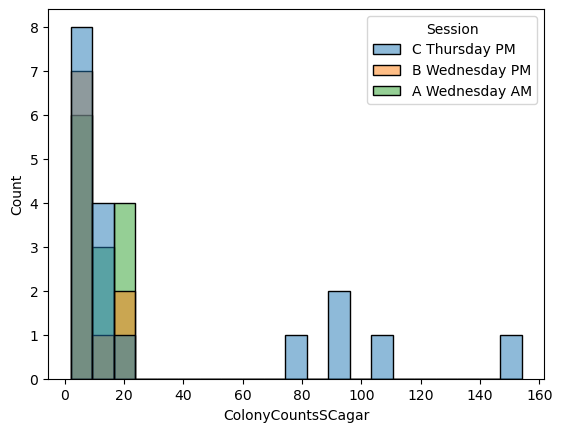

In [13]:
# histogram in SC agar by group - leave more gaps for students.
sns.histplot(data = countdata, x = "ColonyCountsSCagar", hue = "Session")

<Axes: xlabel='ColonyCountsLBagar', ylabel='Session'>

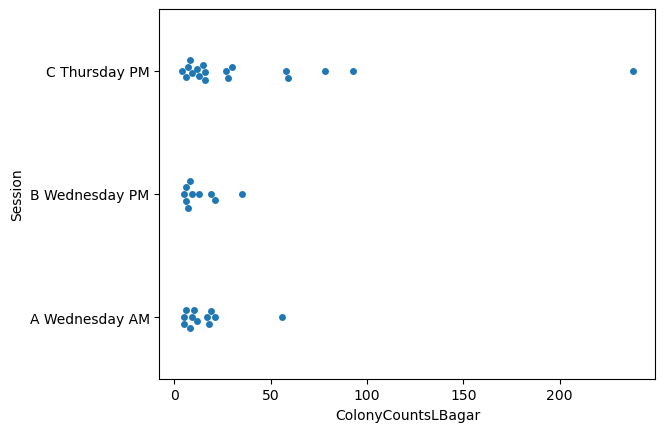

In [14]:
# a different way to plot the data by group, using a swarm plot
sns.swarmplot(data = countdata, x = "ColonyCountsLBagar", y = "Session")

<Axes: xlabel='ColonyCountsSCagar', ylabel='Session'>

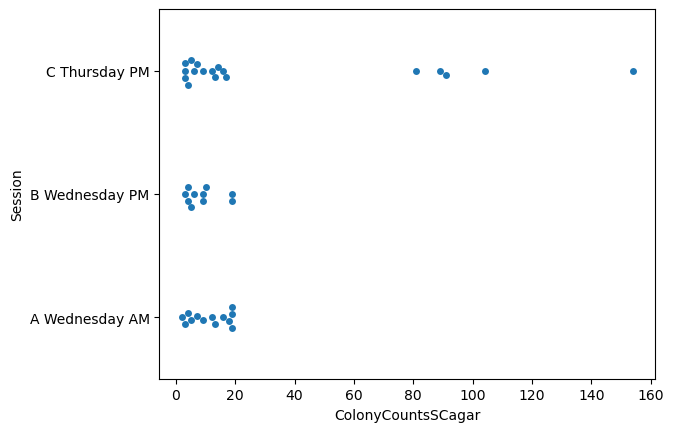

In [15]:
# a different way to plot the data by group, using a swarm plot
sns.swarmplot(data = countdata, x = "ColonyCountsSCagar", y = "Session")

Based on these plots, what do you think about the difference in counts between groups? What is the likely outcome of a statistical test?

The next step is to break up the data into different groups from the lab sessions. Let's remind ourselves what those values are. We can get this using the `.unique()` function.

In [16]:
countdata["Session"].unique()

array(['C Thursday PM', 'B Wednesday PM', 'A Wednesday AM'], dtype=object)

Selecting data based on values takes a few steps. Here, we'll work through those steps briefly, before providing working code for group A. Try to think through what each line of code is doing, and in particular think about what's inside and outside each set of parentheses and quotes.

*Note: in Biology 2A: Data Exploration in Biology, we will do a lot more data analysis like this and give full explanations. This week we're mostly using it as as a tool to get through our data analysis efficiently.*

In [17]:
# Step - find which rows that correspond to group A
countdata["Session"] == 'A Wednesday AM'

0     False
1     False
2     False
3      True
4     False
5     False
6      True
7     False
8     False
9     False
10    False
11    False
12     True
13    False
14     True
15    False
16     True
17     True
18     True
19     True
20     True
21     True
22     True
23    False
24    False
25     True
26     True
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40     True
41    False
Name: Session, dtype: bool

In [18]:
# Next step - select rows from countdata that correspond to group A
countdata[countdata["Session"] == 'A Wednesday AM']

,ID,Session,Group,ColonyCountsLBagar,ColonyTypesLBagar,ColonyCountsSCagar,ColonyTypesSCagar
3,4,A Wednesday AM,15,5.0,2.0,4.0,1.0
6,7,A Wednesday AM,15,8.0,3.0,12.0,4.0
12,13,A Wednesday AM,4,NaN,NaN,NaN,NaN
14,15,A Wednesday AM,7,6.0,5.0,7.0,4.0
16,17,A Wednesday AM,15,21.0,3.0,19.0,4.0
17,18,A Wednesday AM,13,10.0,4.0,18.0,2.0
18,19,A Wednesday AM,3,18.0,4.0,2.0,1.0
19,20,A Wednesday AM,6,12.0,5.0,16.0,4.0
20,21,A Wednesday AM,3,5.0,3.0,3.0,3.0
21,22,A Wednesday AM,12,56.0,3.0,9.0,7.0


To simplify the analysis, we'll focus here on colony counts in LB agar. 

In [19]:
# Putting it together - select counts in LB agar group A
CountsLBagar_A = countdata[countdata["Session"] == 'A Wednesday AM']["ColonyCountsLBagar"]
CountsLBagar_A

3      5.0
6      8.0
12     NaN
14     6.0
16    21.0
17    10.0
18    18.0
19    12.0
20     5.0
21    56.0
22    19.0
25     9.0
26     NaN
40    17.0
Name: ColonyCountsLBagar, dtype: float64

Create the colony counts in groups B and C yourself by adapting the code above. Be sure to spell the values correctly - copy-paste from those unique values if helpful.

Double-check these counts correspond with what you've seen on the histograms above!


In [20]:
# Select counts in LB agar group B - edit to gaps for students
CountsLBagar_B = countdata[countdata["Session"] == 'B Wednesday PM']["ColonyCountsLBagar"]
CountsLBagar_B

2     13.0
15     9.0
24    35.0
27     6.0
30    21.0
31     7.0
32     6.0
33    19.0
35     5.0
36     8.0
Name: ColonyCountsLBagar, dtype: float64

In [21]:
# Select counts in LB agar group C - edit to gaps for students
CountsLBagar_C = countdata[countdata["Session"] == 'C Thursday PM']["ColonyCountsLBagar"]
CountsLBagar_C

0      16.0
1      15.0
4      16.0
5     238.0
7       8.0
8      30.0
9      12.0
10      7.0
11     59.0
13      4.0
23     93.0
28     13.0
29      6.0
34      9.0
37     58.0
38     78.0
39     28.0
41     27.0
Name: ColonyCountsLBagar, dtype: float64

It would help to compute statistics for these groups. Here we do for group A.

In [22]:
# sample means and standard errors, group A
nsamples_A = len(CountsLBagar_A)
smean_LB_A = CountsLBagar_A.mean()
sstd_LB_A  = CountsLBagar_A.std()
SEM_LB_A = sstd_LB_A / math.sqrt(nsamples_A)

print(f'nsamples group A = {nsamples_A:.0f}')
print(f'sample mean LB agar group A = {smean_LB_A:.2f}')
print(f'st.d. LB agar group A = {sstd_LB_A:.2f} ')
print(f'SEM LB agar  group A = {SEM_LB_A:.2f}')

nsamples group A = 14
sample mean LB agar group A = 15.50
st.d. LB agar group A = 13.96 
SEM LB agar  group A = 3.73


Go ahead and calculate these for group B! You can do this efficiently by duplicating the code cell, using copy/paste cell, or by clicking on cell and then on the "Create a duplicate of this cell below" button, that looks like a "+" in a rectangle.

Then, in the duplicated code cell, use find and replace to change all the upper case 'A's to 'B's. 

In [23]:
# sample means and standard errors, group B - leave blank for students
nsamples_B = len(CountsLBagar_B)
smean_LB_B = CountsLBagar_B.mean()
sstd_LB_B  = CountsLBagar_B.std()
SEM_LB_B = sstd_LB_B / math.sqrt(nsamples_B)

print(f'nsamples group B = {nsamples_B:.0f}')
print(f'sample mean LB agar group B = {smean_LB_B:.2f}')
print(f'st.d. LB agar group B = {sstd_LB_B:.2f} ')
print(f'SEM LB agar  group B = {SEM_LB_B:.2f}')

nsamples group B = 10
sample mean LB agar group B = 12.90
st.d. LB agar group B = 9.56 
SEM LB agar  group B = 3.02


In [24]:
# sample means and standard errors, group C - leave blank for students
nsamples_C = len(CountsLBagar_C)
smean_LB_C = CountsLBagar_C.mean()
sstd_LB_C  = CountsLBagar_C.std()
SEM_LB_C = sstd_LB_C / math.sqrt(nsamples_C)

print(f'nsamples group C = {nsamples_C:.0f}')
print(f'sample mean LB agar group C = {smean_LB_C:.2f}')
print(f'st.d. LB agar group C = {sstd_LB_C:.2f} ')
print(f'SEM LB agar  group C = {SEM_LB_C:.2f}')

nsamples group C = 18
sample mean LB agar group C = 39.83
st.d. LB agar group C = 56.03 
SEM LB agar  group C = 13.21


## Statistical tests for differences in counts between groups

Now we have organised the data and calculated the means, there's probably a clear idea of what we'll find for differences between groups. Let's do the statistical test. We will do 3 tests, comparing all pairs of groups.

First compare group A to group B.

In [25]:
# compare group A and group B using the two sample t-test function from scipy.stats
# edit down
t, p = stats.ttest_ind( CountsLBagar_A, CountsLBagar_B, nan_policy = 'omit') 

# Print t 2 decimal places
print(f't A vs B = {t:.2f}')

# Print the p-value to 4 decimal places
print(f'p-value A vs B= {p:.4f}')

t A vs B = 0.50
p-value A vs B= 0.6235


Then compare the other pairs of groups: A to C, then B to C. You can copy code above in order to do that.

In [26]:
# compare group A and group C
# remove for students

t, p = stats.ttest_ind( CountsLBagar_A, CountsLBagar_C, nan_policy = 'omit')

# Print t 2 decimal places
print(f't A vs B = {t:.2f}')

# Print the p-value to 4 decimal places
print(f'p-value A vs B= {p:.4f}')

t A vs B = -1.47
p-value A vs B= 0.1537


In [27]:
# compare group B and group C
# remove for students

t, p = stats.ttest_ind( CountsLBagar_B, CountsLBagar_C, nan_policy = 'omit')

# Print t 2 decimal places
print(f't A vs B = {t:.2f}')

# Print the p-value to 4 decimal places
print(f'p-value A vs B= {p:.4f}')

t A vs B = -1.50
p-value A vs B= 0.1468


Hopefully, you have some t-statistics and p-values. How do the results of the statistical tests compare to the histograms?

If you're interested in learning more about the data, there are other comparisons that you could make using the same ideas and adapting code. For example, you could compare colony counts between groups SC agar media. Or, you could ask about how colony types vary.

In [28]:
# code cells to encourage your own data exploration


## Concluding thoughts

What did you learn from this statistical analysis? How confident are you about the results?

Do you think the real numbers of colony counts are different on LB agar and SC agar?

What do you think about the variability in counts within each group and between groups? How does the variability here compare to the simulated data in workshop 5?

What would you change in the experimental design or execution, if you did this again?

If you see ambiguous results in the end of project report, how would you write them up?